### ＡIプログラミング2 9,10回目<br>

# 2.CNN(畳み込みニューラルネットワーク)
Convlution Neural Network

## 2.1画像データCIFA-10の読み込みとデータの加工

###(1)画像データの表示

Files already downloaded and verified
データの数: 10000


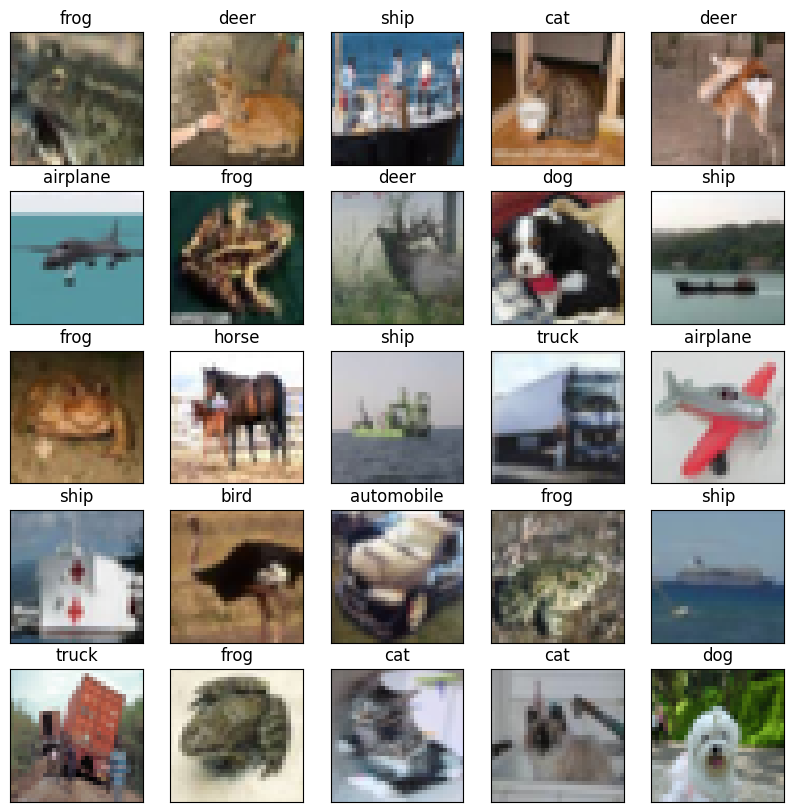

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transforms.ToTensor())
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]
print("データの数:", len(cifar10_data))

n_image = 25  # 表示する画像の数
cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)  # イテレータ: 要素を順番に取り出せるようにする
#images, labels = dataiter.next()  # 最初のバッチを取り出す
images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))  # チャンネルを一番後の次元に
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)  # 軸を非表示に
    ax.get_yaxis().set_visible(False)

plt.show()

###(2)画像データのリサイズ

Files already downloaded and verified


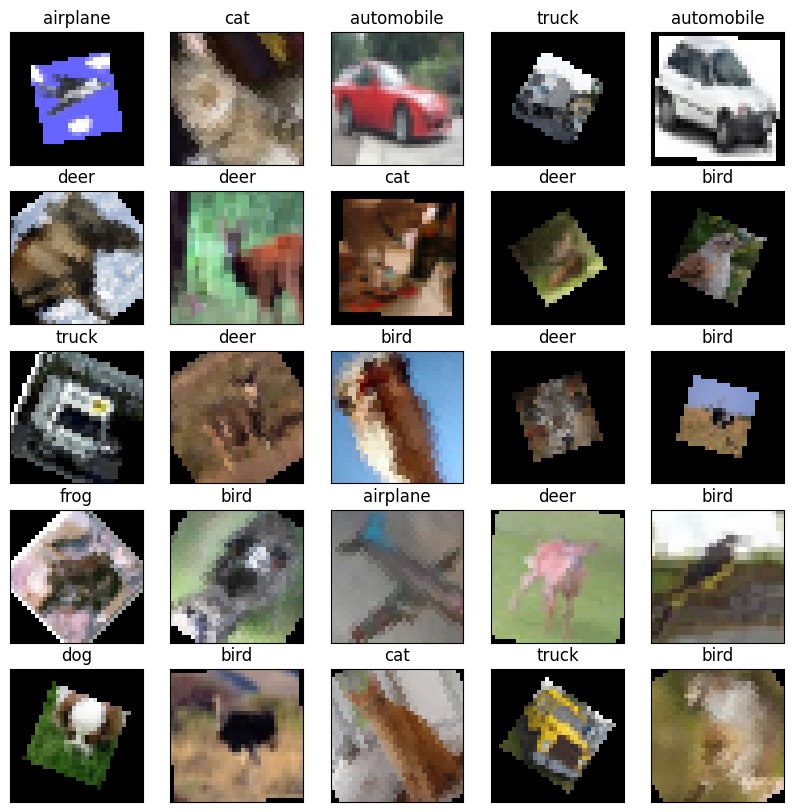

In [ ]:
transform = transforms.Compose([transforms.RandomAffine((-45, 45), scale=(0.5, 1.5)),  # 回転とリサイズ
                                transforms.ToTensor()])
cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transform)

cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)

images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

###(3)データの拡張シフト

Files already downloaded and verified


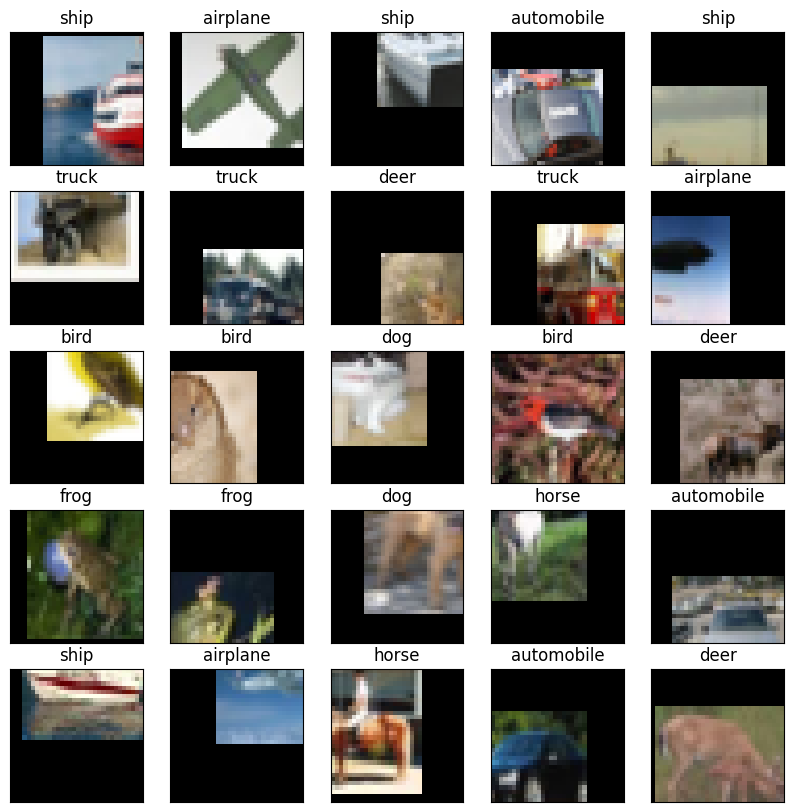

In [ ]:
transform = transforms.Compose([transforms.RandomAffine((0, 0), translate=(0.5, 0.5)),  # 上下左右へのシフト
                                transforms.ToTensor()])
cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transform)

cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

###データの反転

Files already downloaded and verified


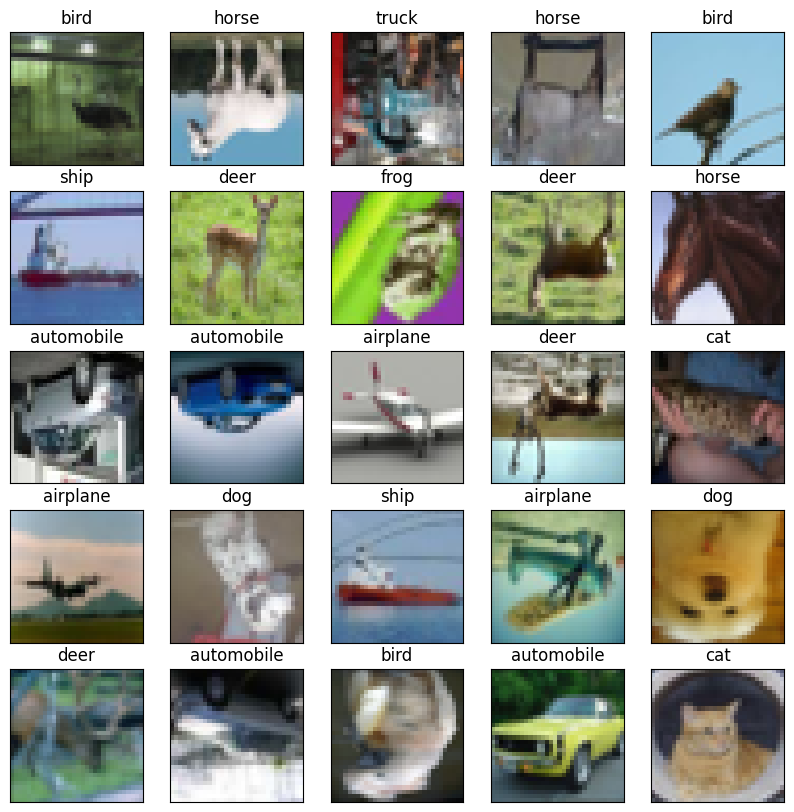

In [ ]:
transform = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5),  # 左右反転
                                transforms.RandomVerticalFlip(p=0.5),  # 上下反転
                                transforms.ToTensor()])
cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transform)

cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

# 2.2画像の学習

##(1)データの読み込み

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

affine = transforms.RandomAffine((-30, 30), scale=(0.8, 1.2))  # 回転とリサイズ
flip = transforms.RandomHorizontalFlip(p=0.5)  # 左右反転
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))  # 平均値を0、標準偏差を1に
to_tensor = transforms.ToTensor()

transform_train = transforms.Compose([affine, flip, to_tensor, normalize])
transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

100%|██████████| 170498071/170498071 [00:04<00:00, 42363722.99it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


##(2)CNNモデルの構築

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 5)  # 畳み込み層:(入力チャンネル数, フィルタ数、フィルタサイズ)
        self.relu = nn.ReLU()  # ReLU
        self.pool = nn.MaxPool2d(2, 2)  # プーリング層:（領域のサイズ, 領域の間隔）
        self.conv2 = nn.Conv2d(8, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 256)  # 全結合層
        self.dropout = nn.Dropout(p=0.5)  # ドロップアウト:(p=ドロップアウト率)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        print("shape1", x.shape)
        x = self.relu(self.conv1(x))
        print("shape2", x.shape)
        x = self.pool(x)
        print("shape3", x.shape)
        x = self.relu(self.conv2(x))
        print("shape4", x.shape)
        x = self.pool(x)
        print("shape5", x.shape)
        x = x.view(-1, 16*5*5)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = Net()
net.cuda()  # GPU対応
print(net)

Net(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


###(3)モデルの訓練

In [ ]:
from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(20):  # 20エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

ストリーミング出力は最後の 5000 行に切り捨てられました。
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64,

###(4)誤差のグラフ化

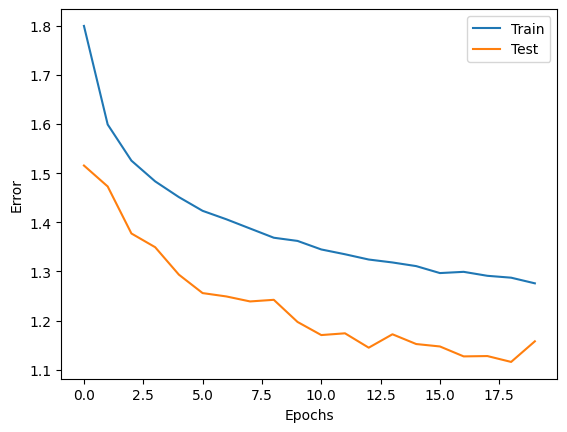

shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([64, 16, 10, 10])
shape5 torch.Size([64, 16, 5, 5])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 8, 28, 28])
shape3 torch.Size([64, 8, 14, 14])
shape4 torch.Size([6

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

#正解データの表示
correct = 0
total = 0
net.eval()  # 評価モード
for i, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率:", str(correct/total*100) + "%")

###(5)データを表示してみる

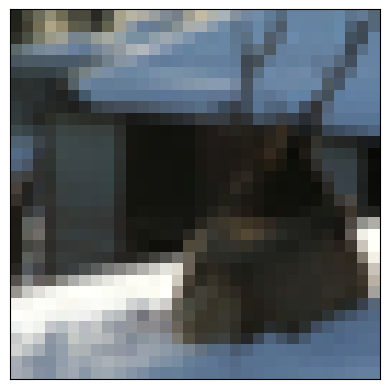

shape1 torch.Size([1, 3, 32, 32])
shape2 torch.Size([1, 8, 28, 28])
shape3 torch.Size([1, 8, 14, 14])
shape4 torch.Size([1, 16, 10, 10])
shape5 torch.Size([1, 16, 5, 5])
予測結果: tensor(3, device='cuda:0')
予測結果2: 3
正解: deer 予測結果: cat


In [ ]:
cifar10_loader = DataLoader(cifar10_test, batch_size=1, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)  # サンプルを1つだけ取り出す

plt.imshow(images[0].permute(1, 2, 0))  # チャンネルを一番後ろに
plt.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)  # ラベルとメモリを非表示に
plt.show()

net.eval()  # 評価モード
x, t = images.cuda(), labels.cuda()  # GPU対応
#x, t = images, labels  # GPU対応無
y = net(x)
print("予測結果:", y.argmax())
print("予測結果2:", y.argmax().item())
print("正解:", cifar10_classes[labels[0]],
      "予測結果:", cifar10_classes[y.argmax().item()])

#課題2<br>
CIFA-10に対して、CNNの構成のうち、<br>
全結合層を追加したとき<br>
損失や正解率違いについて考察しなさい。

Using downloaded and verified file: ./data/cifar-10-python.tar.gz
Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Net(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=20, bias=True)
)
Epoch: 0 Loss_Train: 1.9398795713853958 Loss_Test: 1.5942765208566265
Epoch: 1 Loss_Train: 1.6161511326994737 Loss_Test: 1.445085649277754
Epoch: 2 Loss_Train: 1.5056172783112587 Loss_Test: 1.3395611571658188
Epoch: 3 Loss_Train: 1.4353137821187754 Loss_Test: 1.273625346505718
Epoch: 4 Loss_Train: 1.3857890445253123 Loss_Test: 1.2552190180037432
Epoch: 5 Loss_Train: 1.355867994563354 Lo

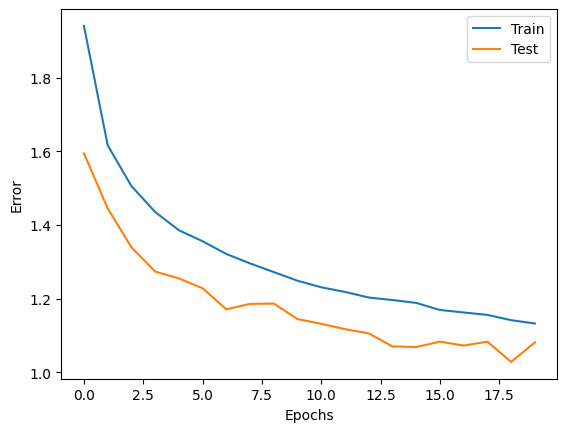

正解率: 62.11%


In [ ]:
#データの取得
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

#画像データをちょっとずつ変更して学習データを増やす
affine = transforms.RandomAffine((-30, 30), scale=(0.8, 1.2))  # 回転とリサイズ
flip = transforms.RandomHorizontalFlip(p=0.5)  # 左右反転
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))  # 平均値を0、標準偏差を1に
to_tensor = transforms.ToTensor()

transform_train = transforms.Compose([affine, flip, to_tensor, normalize])
transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

##CNNのモデルの構築(定義)
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 5)  #
        self.relu = nn.ReLU()  # ReLU
        self.pool = nn.MaxPool2d(2, 2)  # ）
        self.conv2 = nn.Conv2d(8, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 256)  # 全結合層
        self.dropout = nn.Dropout(p=0.5)  # )
        self.fc3 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 20)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16*5*5)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = Net()
net.cuda()  # GPU対応
print(net)

##モデルの訓練
from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(20):  # 20エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

##誤差のグラフ化
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

#正解データの表示
correct = 0
total = 0
net.eval()  # 評価モード
for i, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率:", str(correct/total*100) + "%")

# 課題3<br>
CNNの構成のうち、全結合層を追加したとき<br>
損失や正解率違いについて考察しなさい。

ストリーミング出力は最後の 5000 行に切り捨てられました。
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 t

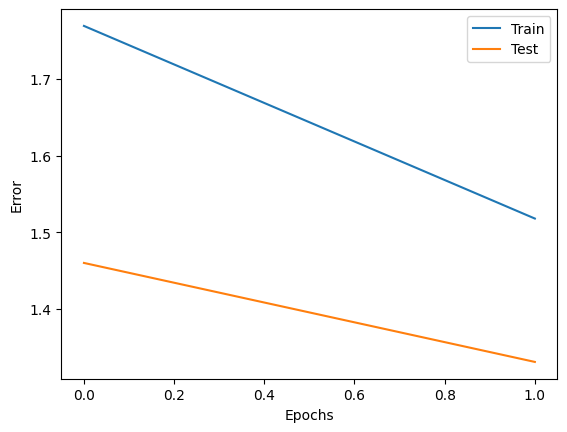

shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape2 torch.Size([64, 24, 28, 28])
shape3 torch.Size([64, 24, 14, 14])
shape4 torch.Size([64, 24, 10, 10])
shape5 torch.Size([64, 24, 5, 5])
shape7 torch.Size([64, 24, 5, 5])
shape8 torch.Size([64, 600])
shape1 torch.Size([64, 3, 32, 32])
shape

In [ ]:
#データの取得
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

#画像データをちょっとずつ変更して楽手データを増やす
affine = transforms.RandomAffine((-30, 30), scale=(0.8, 1.2))  # 回転とリサイズ
flip = transforms.RandomHorizontalFlip(p=0.5)  # 左右反転
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))  # 平均値を0、標準偏差を1に
to_tensor = transforms.ToTensor()

transform_train = transforms.Compose([affine, flip, to_tensor, normalize])
transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

##CNNのモデルの構築(定義)
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 24, 5)  # 畳み込み層:(入力チャンネル数, フィルタ数、フィルタサイズ)
        self.relu = nn.ReLU()  # ReLU
        self.pool = nn.MaxPool2d(2, 2)  # プーリング層:（領域のサイズ, 領域の間隔）
        self.conv2 = nn.Conv2d(24, 24, 5)
        self.fc1 = nn.Linear(24*5*5, 256)  # 全結合層
        self.dropout = nn.Dropout(p=0.5)  # ドロップアウト:(p=ドロップアウト率)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        print("shape1",x.shape)
        x = self.relu(self.conv1(x))
        print("shape2",x.shape)
        x = self.pool(x)
        print("shape3",x.shape)
        x = self.relu(self.conv2(x))
        print("shape4",x.shape)
        x = self.pool(x)
        print("shape5",x.shape)
#        x = self.relu(self.conv3(x))
#        print("shape6",x.shape)
#        x = self.pool(x)
        print("shape7",x.shape)
        x = x.view(-1, 24*5*5)
        print("shape8",x.shape)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = Net()
net.cuda()  # GPU対応
print(net)

##モデルの訓練
from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(2):  # 20エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

##誤差のグラフ化
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

#正解データの表示
correct = 0
total = 0
net.eval()  # 評価モード
for i, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率:", str(correct/total*100) + "%")

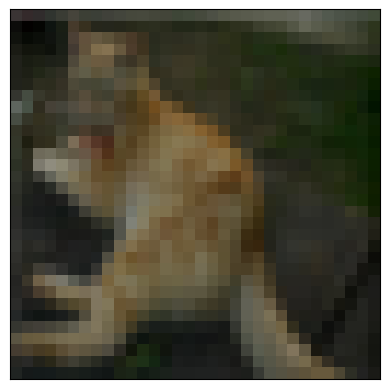

shape1 torch.Size([1, 3, 32, 32])
shape2 torch.Size([1, 24, 28, 28])
shape3 torch.Size([1, 24, 14, 14])
shape4 torch.Size([1, 24, 10, 10])
shape5 torch.Size([1, 24, 5, 5])
shape7 torch.Size([1, 24, 5, 5])
shape8 torch.Size([1, 600])
正解: cat 予測結果: frog


In [ ]:
#データを見てみる
cifar10_loader = DataLoader(cifar10_test, batch_size=1, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)  # サンプルを1つだけ取り出す


#取り出したいデータ場所のインデックスの指定
ei=10

plt.imshow(images[0].permute(1, 2, 0))  # チャンネルを一番後ろに
plt.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)  # ラベルとメモリを非表示に
plt.show()

net.eval()  # 評価モード
x, t = images.cuda(), labels.cuda()  # GPU対応
#x, t = images, labels  # GPU対応無
y = net(x)
print("正解:", cifar10_classes[labels[0]],
      "予測結果:", cifar10_classes[y.argmax().item()])

#課題4<br>
Dropoutを実行するときと、実行しないときの<br>
違いについて比較し考察しなさい。<br>
CNNの構造はどれでも良い。
